In [72]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split


In [221]:
data = load_diabetes()
# print(data.data)
# print(data.target)
X = data.data
Y = data.target
print(len(X))
print(len(Y))
print(data.feature_names)

442
442
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [10]:
train_data, test_data, train_label, test_label = train_test_split(X, Y, test_size = 0.2, random_state = 55)
print(len(train_data))
print(len(train_label))

353
353


In [11]:
print(train_label)

[132. 150. 178. 185. 115. 248. 306. 308. 127.  71. 220. 280. 292.  39.
  72.  87.  85. 121. 135.  55.  74. 310.  55. 148. 163.  48. 134. 167.
  40. 200.  58.  60. 202. 245. 104. 139. 160. 237.  81.  63.  88. 321.
 138. 113. 202.  88. 102.  57.  67. 220. 275. 191. 210. 195. 102. 158.
  91.  90.  77. 230. 235. 160. 115.  66. 179.  68. 181.  61.  48.  65.
  90. 152. 264.  52.  63. 144. 232. 235. 178. 221.  72. 170.  59. 154.
 252. 257. 111. 175. 124. 288.  48.  25.  45.  85. 172. 297. 122. 168.
 200. 122. 274. 197. 302. 249.  69.  39. 216. 199. 158.  83. 136. 277.
 128. 151. 151. 263. 262.  90. 143. 275.  59. 173.  84. 219. 214. 241.
 103.  90.  54. 252. 262.  42. 170.  78. 129. 166.  60. 183. 258. 150.
  75. 273.  72. 192. 145.  61. 281.  96. 140. 150. 296.  67. 261. 121.
 156. 120. 217.  64. 141.  71.  65.  47. 200. 142. 201.  84. 310. 142.
  68.  77. 341. 131. 275.  77.  87. 209. 190. 292.  71. 263. 293. 212.
 229. 111. 346.  88.  84. 295. 131. 104. 279. 303. 332.  85. 187. 270.
 131. 

In [137]:
def model_evaluation(test_label, predicted):
    mse = mean_squared_error(test_label, predicted)
    mape= mean_absolute_percentage_error(test_label, predicted)
    r2= r2_score(test_label, predicted)
    print("mse:",mse)
    print("mape:", mape)
    print("r2_score:", r2)

In [71]:
rm = Ridge(alpha = 0.1)
rm.fit(train_data, train_label)
predicted = rm.predict(test_data)
model_evaluation(test_label, predicted)

mse: 2653.829825150289
mape: 0.391417520709336
r2_score: 0.5250843761441002


In [60]:
lm = Lasso(alpha = 0.4)
lm.fit(train_data, train_label)
predicted = lm.predict(test_data)
model_evaluation(test_label, predicted)

mse: 2843.7547376280313
mape: 0.4297632485416082
r2_score: 0.49109639867834975


In [65]:
em = ElasticNet(alpha = 0.01)
em.fit(train_data, train_label)
predicted = em.predict(test_data)
model_evaluation(test_label, predicted)

mse: 3333.027365528756
mape: 0.4928705503718751
r2_score: 0.40353870635272027


In [73]:
linearM = LinearRegression()
linearM.fit(train_data, train_label)
predicted = linearM.predict(test_data)
model_evaluation(test_label, predicted)


mse: 2702.289813846003
mape: 0.39157459866723393
r2_score: 0.5164122278603752


In [191]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.datasets import load_wine
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [98]:
dt_rm = DecisionTreeRegressor(max_depth = 3)
dt_rm.fit(train_data, train_label)
predict = dt_rm.predict(test_data)
model_evaluation(test_label, predict)

mse: 3163.38678510084
mape: 0.4126369110659224
r2_score: 0.43389670494090715


In [169]:
# plot_tree(dt_rm)

In [222]:
data = load_wine()
X = data.data
Y = data.target
print(len(X))
print(len(Y))
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 55)

178
178


In [188]:
def model_c_evaluation(true_label, predict):
    print(classification_report(true_label, predict))
    print("---- confusion matrix ----")
    print(confusion_matrix(true_label, predict))

In [189]:
dt_cm = DecisionTreeClassifier(max_depth = 5)
dt_cm.fit(x_train, y_train)
predict = dt_cm.predict(x_test)
model_c_evaluation(y_test, predict)

              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.87      0.87      0.87        15
           2       0.86      0.92      0.89        13

    accuracy                           0.89        36
   macro avg       0.91      0.89      0.90        36
weighted avg       0.89      0.89      0.89        36

---- confusion matrix ----
[[ 7  1  0]
 [ 0 13  2]
 [ 0  1 12]]


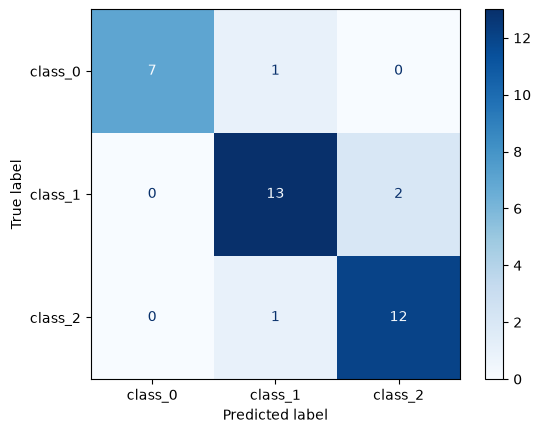

In [195]:
cm = confusion_matrix(y_test, predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [196]:
import numpy as np
print(np.unique(y_test))

[0 1 2]


In [197]:
from sklearn.svm import SVC, SVR


In [204]:
#kernel = rbf (radial basis function), poly, linear
svr = SVR(kernel = "sigmoid")
svr.fit(train_data, train_label)
predict = svr.predict(test_data)
model_evaluation(test_label, predict)

mse: 3329.332694152831
mape: 0.4487231537456922
r2_score: 0.40419988558313324


In [209]:
svc = SVC(kernel = "linear")
svc.fit(x_train, y_train)
predict = svc.predict(x_test)
model_c_evaluation(y_test, predict)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.94      1.00      0.97        15
           2       1.00      0.92      0.96        13

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.98        36
weighted avg       0.97      0.97      0.97        36

---- confusion matrix ----
[[ 8  0  0]
 [ 0 15  0]
 [ 0  1 12]]


In [210]:
from sklearn.datasets import load_breast_cancer
from sklearn.neural_network import MLPClassifier, MLPRegressor


In [223]:
print(data.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [248]:
model = MLPRegressor(hidden_layer_sizes = (8, 8, 8,), activation = "relu")
model.fit(train_data, train_label)
predict = model.predict(test_data)
model_evaluation(test_label, predict)

mse: 9756.24394638637
mape: 0.42052156693757364
r2_score: -0.7459268248392814


C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [251]:
model = MLPClassifier(hidden_layer_sizes = (8, 8, 8), activation = "relu")
model.fit(x_train, y_train)
predict = model.predict(x_test)
model_c_evaluation(y_test, predict)

              precision    recall  f1-score   support

           0       0.73      1.00      0.84         8
           1       0.69      0.60      0.64        15
           2       0.58      0.54      0.56        13

    accuracy                           0.67        36
   macro avg       0.67      0.71      0.68        36
weighted avg       0.66      0.67      0.66        36

---- confusion matrix ----
[[8 0 0]
 [1 9 5]
 [2 4 7]]


C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [252]:
data = load_breast_cancer()
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [272]:
X = data.data
Y = data.target
# print(X)
# print(len(X))
# print(len(Y))
train_feature, test_feature, train_label, test_label = train_test_split(X, Y, test_size = 0.2, random_state = 55)
print(len(train_feature))
print(len(train_label))
# print(len(test_feature))
# x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 55)

455
455


In [279]:
model = MLPClassifier(hidden_layer_sizes = (16, 16, 16), activation = "relu")
model.fit(train_feature, train_label)
predict = model.predict(test_feature)
model_c_evaluation(test_label, predict)

              precision    recall  f1-score   support

           0       0.93      0.86      0.89        49
           1       0.90      0.95      0.93        65

    accuracy                           0.91       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114

---- confusion matrix ----
[[42  7]
 [ 3 62]]


C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
